# Using Machine Learning techniques to predict a stroke

## Imports

In [594]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.base import clone
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import shap

## Load in data, basic data information

In [595]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

file_path = os.path.join(path, "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(file_path)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [596]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## Data cleaning

In [597]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

### Checking data for unique values

Before modifying the data to be fit for training we should check how many unique values each feature can have, so that we can determine how to represent it (eg. use 0 and 1 for yes-no columns or one-hot encoding for those with more posiible values).

In [598]:
for column in df.columns:
    print(f"{column} values: {df[column].unique()}")

id values: [ 9046 51676 31112 ... 19723 37544 44679]
gender values: ['Male' 'Female' 'Other']
age values: [6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00e+00
 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01
 2.80e+01 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00
 1.00e+00 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00
 1.24e+00 8.00e-01

### Adjusting column types

In [599]:
df["age"] = df["age"].astype("uint8")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Checking for NaN values

We check if there are any values missing from the dataset.
- `df.isna()` – returns a DataFrame of True/False values (True if the value in the original DataFrame is NaN, False otherwise)  
- `df.isna().any()` – for each column, checks if it contains at least one True value  
- `df.isna().any().any()` – returns True if there is **at least one NaN** in the original DataFrame, False otherwise

In [600]:
df.isna().any().any()

np.True_

### Dealing with NaNs

BMI is the only columns with missing values. We fill them using the gender average.

In [601]:
df["bmi"] = df["bmi"].fillna(df.groupby("gender")["bmi"].transform("mean"))
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,29.065758,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80,1,0,Yes,Private,Urban,83.75,29.065758,never smoked,0
5106,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


### Modifying the data
To train the models we will convert binary values (Yes/No) to 0s and 1s, and use One-Hot Encoding for features with more than 2 different values.

In [602]:
# Binary to 1/0
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})

# One-Hot Encoding
df = pd.get_dummies(df, columns=["gender", "work_type", "Residence_type", "smoking_status"])

# Convert all bool columns from OHE to int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67,0,1,1,228.69,36.600000,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0
1,51676,61,0,0,1,202.21,29.065758,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0
2,31112,80,0,1,1,105.92,32.500000,1,0,1,0,0,0,1,0,0,1,0,0,0,1,0
3,60182,49,0,0,1,171.23,34.400000,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1
4,1665,79,1,0,1,174.12,24.000000,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0


In [603]:
# Move label to the rightmost side of the dataframe
cols = [c for c in df.columns if c != "stroke"] + ["stroke"]
df = df[cols]

### Renaming the columns

In this step we standardize the naming convention of features in the dataframe.

In [604]:
def get_renamed_column(name):
    name = name.strip()
    name = name.lower()
    name = name.replace(" ", "_")

    return name


def get_rename_dict(column_names):
    rename_dict = {}
    for name in column_names:
        rename_dict[name] = get_renamed_column(name)

    return rename_dict

In [605]:
df = df.rename(columns=get_rename_dict(df.columns))
df.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,gender_female,gender_male,gender_other,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self-employed,work_type_children,residence_type_rural,residence_type_urban,smoking_status_unknown,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smokes,stroke
0,9046,67,0,1,1,228.69,36.600000,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1
1,51676,61,0,0,1,202.21,29.065758,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1
2,31112,80,0,1,1,105.92,32.500000,0,1,0,0,0,1,0,0,1,0,0,0,1,0,1
3,60182,49,0,0,1,171.23,34.400000,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1
4,1665,79,1,0,1,174.12,24.000000,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1


### Check for duplicates

In [606]:
any(df.duplicated())

False

There are only unique records in the dataset already, we may proceed.

### Check for class imbalance

Ideally here should be a similar number of records in each class.

In [607]:
df[df.columns[-1]].sum() / df[df.columns[-1]].size

np.float64(0.0487279843444227)

Since stroke was confirmed only in 5% of patients the imbalance is very serious. We will use a few different techniques to try dealing with it.

## Preparing the train and test sets

In [608]:
print(df.columns)

Index(['id', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'avg_glucose_level', 'bmi', 'gender_female', 'gender_male',
       'gender_other', 'work_type_govt_job', 'work_type_never_worked',
       'work_type_private', 'work_type_self-employed', 'work_type_children',
       'residence_type_rural', 'residence_type_urban',
       'smoking_status_unknown', 'smoking_status_formerly_smoked',
       'smoking_status_never_smoked', 'smoking_status_smokes', 'stroke'],
      dtype='object')


### Dropping features


In [609]:
columns_to_drop = ["id", "ever_married", "gender_female", "gender_male", "gender_other", "work_type_govt_job", "work_type_never_worked",
       "work_type_private", "work_type_self-employed", "work_type_children"]

df = df.drop(columns=columns_to_drop)

### Train-Test Split

In [610]:
X = df.drop(columns=[df.columns[-1]]) 
y = df[df.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Data visualization
In this section we use data visualization tools to gain a better insight.

### Correlation matrix
Correlation matrix allows us to see the linear relations between features.

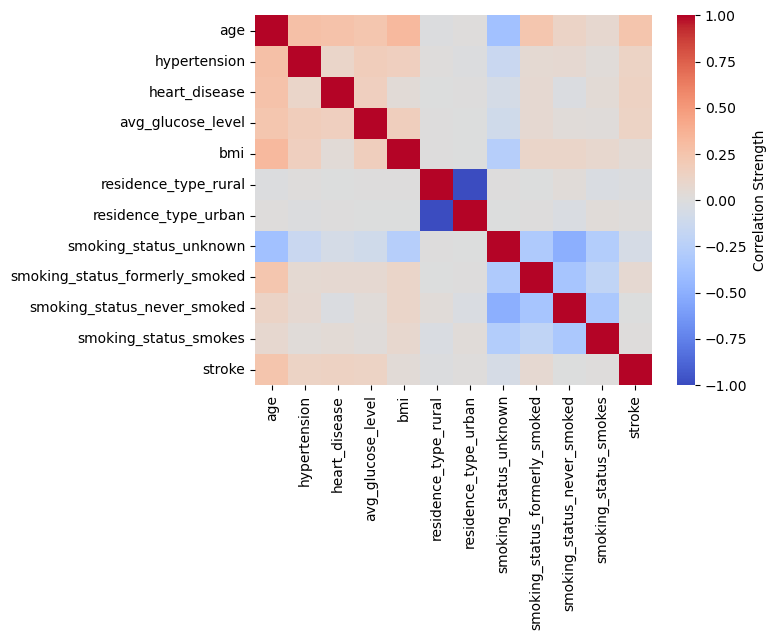

In [611]:
corr = df.corr(numeric_only=True)
ax = sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)

cbar = ax.collections[0].colorbar
cbar.set_label("Correlation Strength")

plt.show()

As seen on the heatmap above, the features most correlated with stroke are: age, hypertension, heart disease and average glucose level. 

## Create models
In this sections we create dictionaries for different types of models that will be used in the later sections.

### Logistic Regression

In [612]:
param_distributions_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["saga"],
    "model__max_iter": [100, 200, 300, 400, 500]
}

### Random Forests

In [613]:
param_distributions_rf = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False]
}

### XGBoost

In [614]:
param_distributions_xgboost = {
    "model__n_estimators": [50, 80, 100, 150, 200],
    "model__max_depth": [3, 5, 7, 10, 12],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
}

### Neural Networks

In [615]:
input_shape = X_train.shape[1]

neural_networks_models = {
    "NN_64_32_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_32_32_32_1": Sequential([
        Dense(32, activation="sigmoid", input_shape=(input_shape,)),
        Dense(32, activation="sigmoid"),
        Dense(32, activation="sigmoid"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(64, activation="tanh"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_128_64_64_1": Sequential([
        Dense(128, activation="relu", input_shape=(input_shape,)),
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_32_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(32, activation="tanh"),
        Dense(64, activation="tanh"),
        Dense(1, activation="sigmoid")
    ]),
}

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train and evaluate models

#### ROC Functions

In [616]:
y_prob_dict_baseline = {}
y_prob_dict_smote = {}

In [617]:
def plot_roc(y_prob_dict):
    plt.figure(figsize=(8, 8))

    for name, y_prob in y_prob_dict.items():
        if y_prob is not None and len(y_prob) > 0:
            false_positive_ratio, true_positive_ratio, _ = roc_curve(y_test, y_prob)
            plt.plot(false_positive_ratio, true_positive_ratio, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

#### Printing metrics

In [618]:
def print_trained_model(model, name, y_prob_dict):
 
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    y_prob_dict[name] = y_prob

    auc_roc = roc_auc_score(y_test, y_prob)
    print(f"AUC ROC: {auc_roc}\n")
    print(f"{classification_report(y_test , y_pred)}\n")   

def print_neural_networks(trained_models, scaler, y_prob_dict):
    X_test_scaled = scaler.transform(X_test)
    for name, model in trained_models.items():
        y_prob = model.predict(X_test_scaled).flatten()

        y_prob_dict[name] = y_prob
        auc_roc = roc_auc_score(y_test, y_prob)

        y_pred = (y_prob > 0.5).astype(int) 

        print(f"{name} AUC ROC: {auc_roc}\n")
        print(f"{classification_report(y_test , y_pred)}\n")  

### Baseline (ignoring the imbalance)
Here we check how the models will behave if we disregard the fact, that data is heavily skewed and try to train the model without doing anything about it. That way we will be able to determine whether these methods are actually helpful.

In [619]:
def train_model_baseline(param_distributions, model, X, y, scoring="f1"):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    search.fit(X, y)

    return search

In [620]:
def train_neural_networks(models, X, y, optimizer=Adam, lr=0.001, class_weight=None, epochs=50):
    results = {}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for name, model in models.items():
        model_copy = clone_model(model)
        model_copy.set_weights(model.get_weights()) 
        
        opt = optimizer(learning_rate=lr)
        model_copy.compile(opt, loss="binary_crossentropy", metrics=["precision", "recall"])
        model_copy.fit(X_scaled, y, epochs=epochs, batch_size=32, verbose=0, class_weight=class_weight, validation_split=0.2)

        results[name] = model_copy

    return results, scaler

#### Baseline for Logistic Regression

In [621]:
baseline_lr = train_model_baseline(param_distributions_lr, LogisticRegression(), X_train, y_train).best_estimator_
print_trained_model(baseline_lr, "Logistic Regression", y_prob_dict_baseline)

AUC ROC: 0.8474677407324531

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       981
           1       0.00      0.00      0.00        41

    accuracy                           0.96      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.92      0.96      0.94      1022




c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

#### Baseline for Random Forest

In [622]:
baseline_rf = train_model_baseline(param_distributions_rf, RandomForestClassifier(), X_train, y_train).best_estimator_
print_trained_model(baseline_rf, "Random Forest", y_prob_dict_baseline)

AUC ROC: 0.6373660525596081

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       981
           1       0.17      0.17      0.17        41

    accuracy                           0.93      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.93      0.93      0.93      1022




##### SHAP Plots

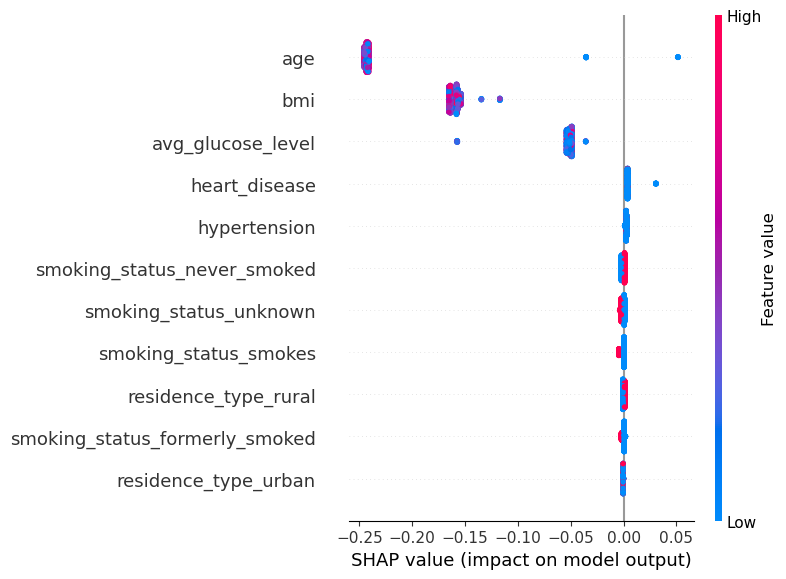

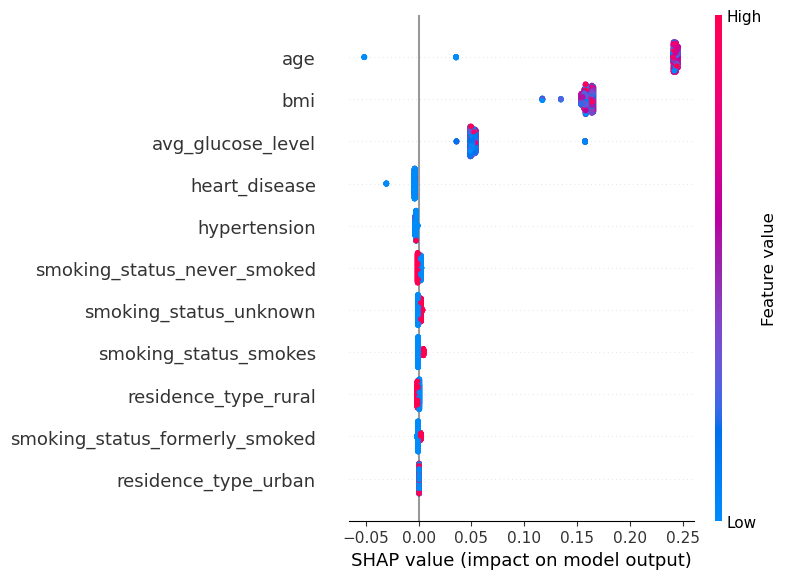

In [623]:
explainer = shap.Explainer(baseline_rf.named_steps["model"])
shap_values = explainer(X_test)
shap.summary_plot(shap_values[:, :, 0], X_test)
shap.summary_plot(shap_values[:, :, 1], X_test)

#### Baseline for XGBoost

In [624]:
baseline_xgb = train_model_baseline(param_distributions_xgboost, XGBClassifier(), X_train, y_train).best_estimator_
print_trained_model(baseline_xgb, "XGBoost", y_prob_dict_baseline)

AUC ROC: 0.7789463215733075

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.18      0.10      0.13        41

    accuracy                           0.95      1022
   macro avg       0.57      0.54      0.55      1022
weighted avg       0.93      0.95      0.94      1022




##### SHAP Plot

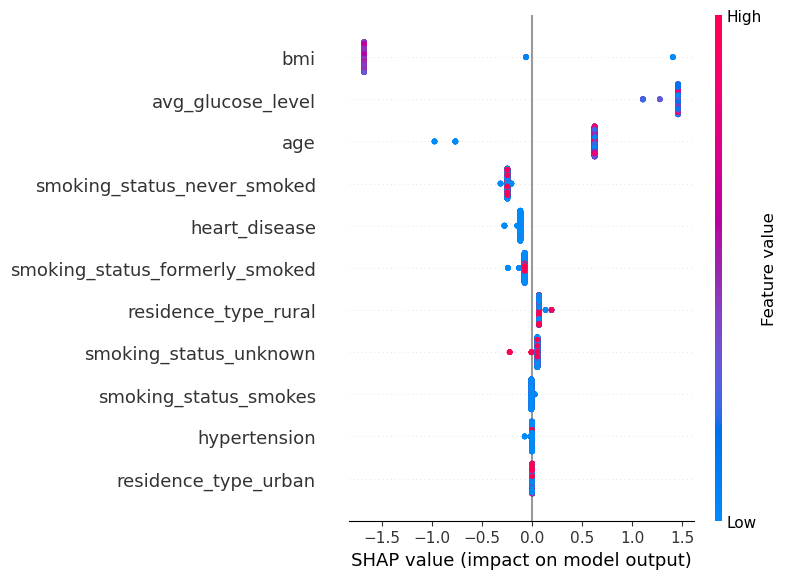

In [625]:
explainer = shap.Explainer(baseline_xgb.named_steps["model"])
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

#### Baseline for Neural Networks

In [626]:
trained_models, scaler = train_neural_networks(neural_networks_models, X_train, y_train)
print_neural_networks(trained_models, scaler, y_prob_dict_baseline)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
NN_64_32_1 AUC ROC: 0.8187016732552647

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       981
           1       0.50      0.02      0.05        41

    accuracy                           0.96      1022
   macro avg       0.73      0.51      0.51      1022
weighted avg       0.94      0.96      0.94      1022


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
NN_32_32_32_1 AUC ROC: 0.8448323015340244

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       981
           1       0.00      0.00      0.00        41

    accuracy                           0.96      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.92      0.96      0.94      1022


 1/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
NN_64_64_1 AUC ROC: 0.8193729643718455

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       981
           1       0.00      0.00      0.00        41

    accuracy                           0.96      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.92      0.96      0.94      1022


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
NN_128_64_64_1 AUC ROC: 0.7933666492628229

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.11      0.05      0.07        41

    accuracy                           0.95      1022
   macro avg       0.54      0.52      0.52      1022
weighted avg       0.93      0.95      0.94      1022


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
NN_64_1 AUC ROC: 0.8328236493374108

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       9

#### ROC

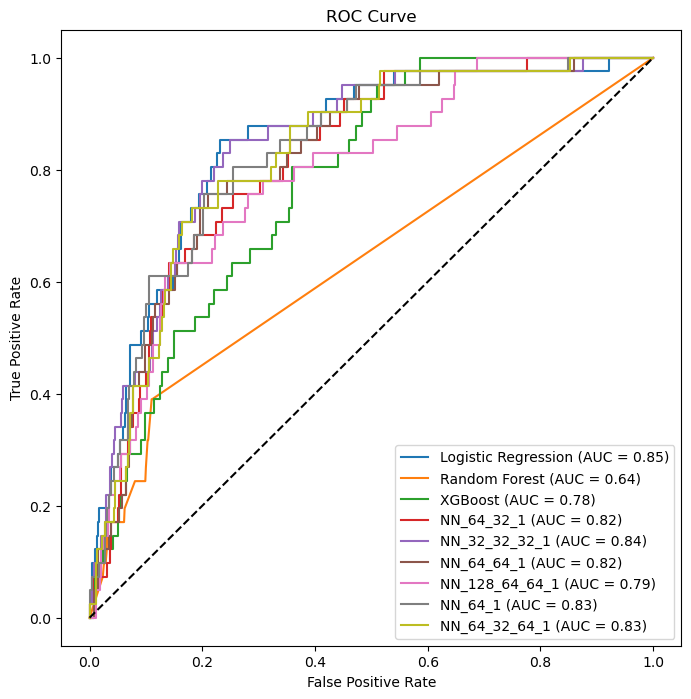

In [627]:
plot_roc(y_prob_dict_baseline)

### Using SMOTE to deal with class imbalance
SMOTE is an oversampling technique that enhances the training data set with synthetically created records for the minority class. 

In [628]:
def train_model_smote(param_distributions, model, X, y, scoring="f1"):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy="minority")),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    search.fit(X, y)

    return search

#### SMOTE + Logistic Regression

In [629]:
best_model = train_model_smote(param_distributions_lr, LogisticRegression(), X_train, y_train).best_estimator_
print_trained_model(best_model, "Logistic Regression", y_prob_dict_smote)

AUC ROC: 0.8493075756445638

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       981
           1       0.12      0.85      0.21        41

    accuracy                           0.74      1022
   macro avg       0.56      0.80      0.53      1022
weighted avg       0.96      0.74      0.82      1022




##### SMOTE + Random Forest

In [630]:
best_model = train_model_smote(param_distributions_rf, RandomForestClassifier(), X_train, y_train).best_estimator_
print_trained_model(best_model, "Random Forest", y_prob_dict_smote)

AUC ROC: 0.8469456254195569

              precision    recall  f1-score   support

           0       0.99      0.69      0.81       981
           1       0.11      0.88      0.19        41

    accuracy                           0.70      1022
   macro avg       0.55      0.78      0.50      1022
weighted avg       0.96      0.70      0.79      1022




##### SHAP Plots

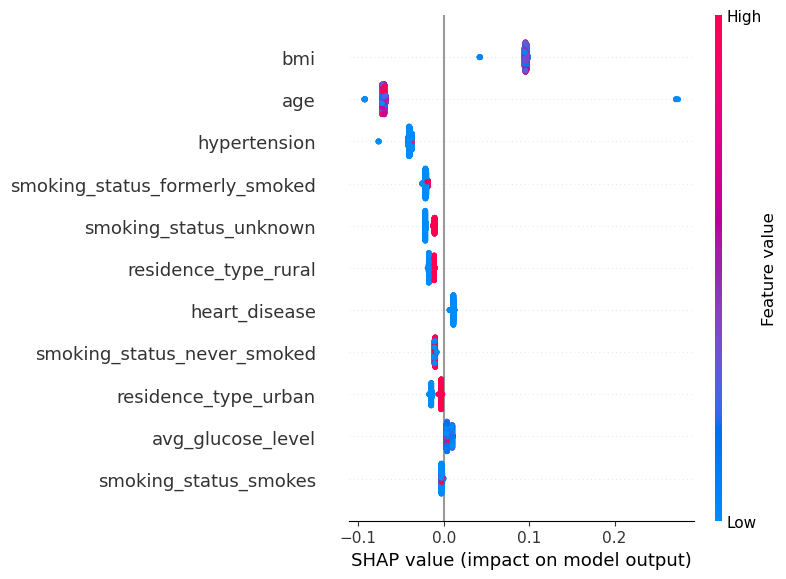

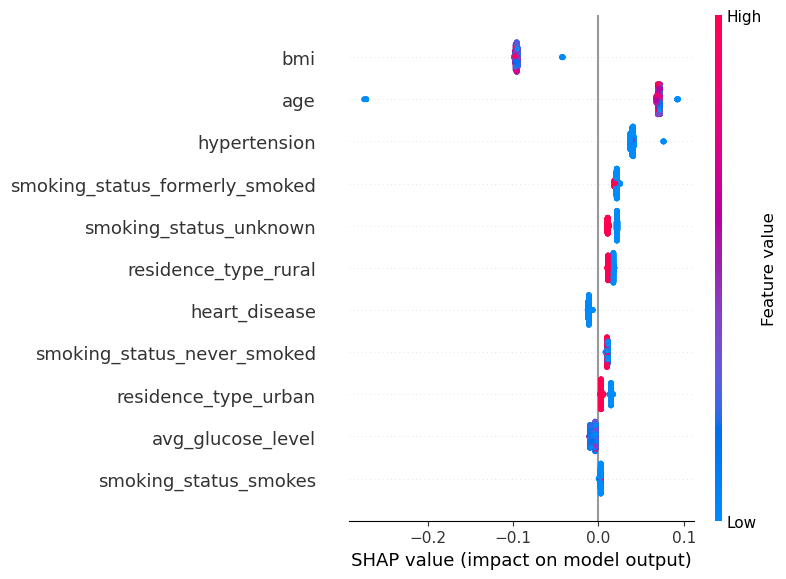

In [631]:
explainer = shap.Explainer(best_model.named_steps["model"])
shap_values = explainer(X_test)
shap.summary_plot(shap_values[:, :, 0], X_test)
shap.summary_plot(shap_values[:, :, 1], X_test)

##### SMOTE + XGBoost

In [632]:
best_model = train_model_smote(param_distributions_xgboost, XGBClassifier(), X_train, y_train).best_estimator_
print_trained_model(best_model, "XGBoost", y_prob_dict_smote)

AUC ROC: 0.837261629497029

              precision    recall  f1-score   support

           0       0.99      0.78      0.87       981
           1       0.13      0.76      0.22        41

    accuracy                           0.78      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.95      0.78      0.84      1022




##### SHAP Plot

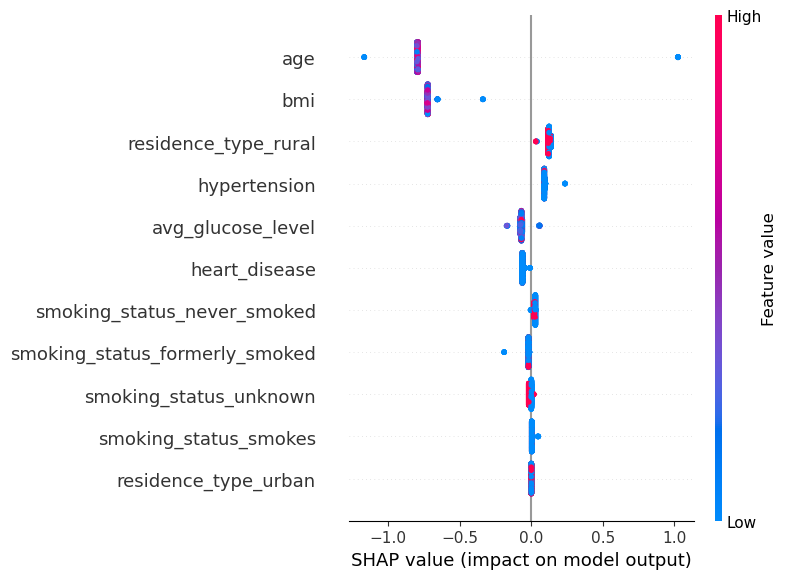

In [633]:
explainer = shap.Explainer(best_model.named_steps["model"])
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

#### ROC

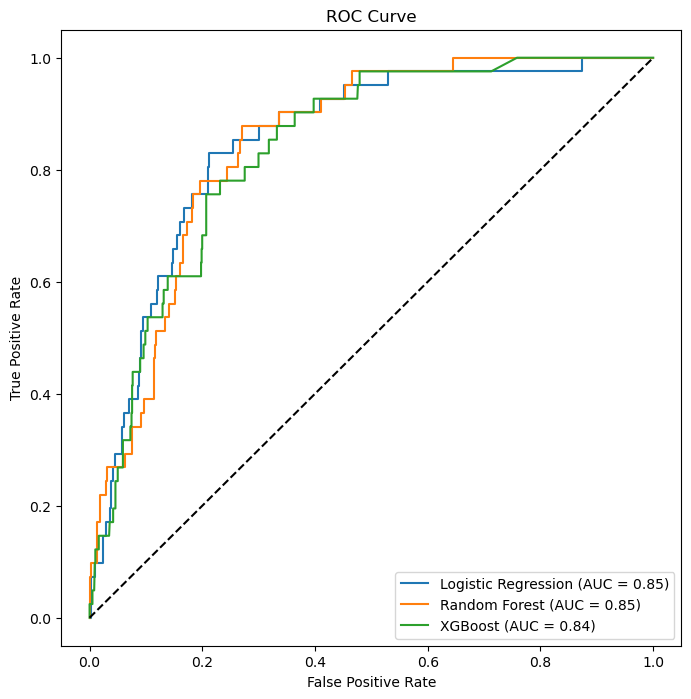

In [634]:
plot_roc(y_prob_dict_smote)

### Using Ensemble to deal with class imbalance

In [635]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns).reset_index(drop=True)
y_train_ensemble = y_train.copy().reset_index(drop=True)

ensemble_set = pd.concat((X_train_scaled, y_train_ensemble), axis="columns")

# Divide the ensemble set by the label
ensemble_class_0 = ensemble_set[ensemble_set[ensemble_set.columns[-1]] == 0]
ensemble_class_1 = ensemble_set[ensemble_set[ensemble_set.columns[-1]] == 1]

# Create train and test sets
X_train_class_0 = ensemble_class_0.drop(ensemble_class_0.columns[-1], axis="columns")
y_train_class_0 = ensemble_class_0[ensemble_class_0.columns[-1]]

X_train_class_1 = ensemble_class_1.drop(ensemble_class_1.columns[-1], axis="columns")
y_train_class_1 = ensemble_class_1[ensemble_class_1.columns[-1]]

# Estimate the number of sub models required and the numer of class 0 records per each sub model
sub_models_count = int(len(X_train_class_0) / len(X_train_class_1))
records_per_set = len(X_train_class_0) // sub_models_count

In [636]:
def create_ensemble_model(model_count, param_distributions, model):
    ensemble_model = []
    for i in range(model_count):
        for j in range(sub_models_count):
            X_chunk = X_train_class_0.sample(n=records_per_set, replace=True)
            y_chunk = y_train_class_0.loc[X_chunk.index]
            current_X_train = pd.concat((X_chunk, X_train_class_1), axis="rows")
            current_y_train = pd.concat((y_chunk, y_train_class_1), axis="rows")

            trained_model = train_model_baseline(param_distributions, model, current_X_train, current_y_train).best_estimator_
            ensemble_model.append(trained_model)

    return ensemble_model

In [639]:
def print_ensemble_metrics(ensemble_model):
    votes = np.zeros(len(X_test))
    for model in ensemble_model:
        
        prob = model.predict_proba(X_test)[:, 1]
        votes += prob

    avg_prob = votes / len(model)
    auc_roc = roc_auc_score(y_test, avg_prob)
    
    y_pred = (avg_prob > 0.5).astype(int)

    print(f"AUC ROC: {auc_roc}\n")
    print(f"{classification_report(y_test , y_pred)}\n")  

In [640]:
ensemble_model = create_ensemble_model(sub_models_count, param_distributions_lr, LogisticRegression())
print_ensemble_metrics(ensemble_model)

AUC ROC: 0.7233659033838046

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       981
           1       0.04      1.00      0.08        41

    accuracy                           0.04      1022
   macro avg       0.02      0.50      0.04      1022
weighted avg       0.00      0.04      0.00      1022




c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

### Using class weight to deal with the imbalance

In [641]:
y_prob_dict_class_weight = {}

In [642]:
trained_models, scaler = train_neural_networks(neural_networks_models, X_train, y_train, class_weight={0: 1, 1:19})
print_neural_networks(trained_models, scaler, y_prob_dict_class_weight)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
NN_64_32_1 AUC ROC: 0.8104721414186619

              precision    recall  f1-score   support

           0       0.99      0.79      0.88       981
           1       0.13      0.76      0.23        41

    accuracy                           0.79      1022
   macro avg       0.56      0.78      0.55      1022
weighted avg       0.95      0.79      0.85      1022


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
NN_32_32_32_1 AUC ROC: 0.8446334004624451

              precision    recall  f1-score   support

           0       0.99      0.65      0.79       981
           1       0.10      0.88      0.17        41

    accuracy                           0.66      1022
   macro avg       0.54      0.77      0.48      1022
weighted avg       0.96      0.66      0.76      1022


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
NN_64_64_1 AUC ROC: 0.8470948012232417

              precision    recall  f1-score   support

           0       0.99      0.79      0.88     

## Model comparison

## Conclusions